
## Partie 6 — Démarrage : charger, inspecter, premier .fit()

In [14]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    roc_auc_score, recall_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt
import joblib

In [ ]:
def charger_donnees(path='../data/bank_processed.csv'):
    df = pd.read_csv(path)
    print('Shape :', df.shape)
    print('\nDistribution de la cible :')
    print(df['y'].value_counts(normalize=True).round(3))
    return df


def preparer_features(df):
    df_clean = pd.get_dummies(df, drop_first=True).dropna()
    X = df_clean.drop(columns=['y_yes'])
    y = df_clean['y_yes']
    print('Features :', X.shape[1])
    print('Positifs (yes) :', y.sum(), f'({y.mean():.1%})')
    return X, y


def splitter(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print('Train :', X_train.shape[0], 'lignes')
    print('Test  :', X_test.shape[0], 'lignes')
    return X_train, X_test, y_train, y_test


def evaluer_baseline(X_train, X_test, y_train, y_test):
    baseline = LogisticRegression(max_iter=1000, random_state=42)
    baseline.fit(X_train, y_train)
    roc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])
    rec = recall_score(y_test, baseline.predict(X_test))
    print(f'Baseline logistique — ROC-AUC : {roc:.3f} | Recall (yes) : {rec:.3f}')
    print('\n✅ Pipeline de bout en bout opérationnel')
    return baseline

In [16]:
df = charger_donnees()
df.head()

Shape : (45211, 17)

Distribution de la cible :
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [17]:
X, y = preparer_features(df)
X_train, X_test, y_train, y_test = splitter(X, y)
baseline = evaluer_baseline(X_train, X_test, y_train, y_test)

Features : 38
Positifs (yes) : 5289 (11.7%)
Train : 36168 lignes
Test  : 9043 lignes
Baseline logistique — ROC-AUC : 0.893 | Recall (yes) : 0.308

✅ Pipeline de bout en bout opérationnel



## Partie 7 L'Arène : 3 algos, même split, même métrique

In [ ]:
def lancer_arene(X_train, X_test, y_train, y_test):
    competiteurs = {
        # balanced : recall 0.308→0.795 sans perte de ROC-AUC
        'Régression logistique': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        # RF bootstrap déjà robuste au déséquilibre : balanced baisse le recall (0.390→0.335)
        'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    }
    resultats = []
    for nom, modele in competiteurs.items():
        t0 = time.perf_counter()
        modele.fit(X_train, y_train)
        duree = time.perf_counter() - t0
        roc = roc_auc_score(y_test, modele.predict_proba(X_test)[:, 1])
        rec = recall_score(y_test, modele.predict(X_test))
        resultats.append({'Algo': nom, 'ROC-AUC': roc, 'Recall (yes)': rec, 'Temps (s)': round(duree, 2)})
    leaderboard = pd.DataFrame(resultats).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    leaderboard.index += 1
    print('=== LEADERBOARD ===')
    return competiteurs, leaderboard


def valider_champion(competiteurs, leaderboard, X, y, cv=5):
    champion_nom = leaderboard.iloc[0]['Algo']
    champion = competiteurs[champion_nom]
    scores_cv = cross_val_score(champion, X, y, cv=cv, scoring='roc_auc')
    print(f'Champion : {champion_nom}')
    print(f'ROC-AUC cross-val {cv}-fold : {scores_cv.mean():.3f} (± {scores_cv.std():.3f})')
    return champion, champion_nom


def afficher_resultats(champion, X_test, y_test):
    y_pred = champion.predict(X_test)
    print('=== Matrice de confusion ===')
    print(confusion_matrix(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred, target_names=['no', 'yes']))


def tracer_roc(competiteurs, X_test, y_test):
    fig, ax = plt.subplots(figsize=(7, 5))
    for nom, modele in competiteurs.items():
        RocCurveDisplay.from_estimator(modele, X_test, y_test, ax=ax, name=nom)
    ax.set_title('Courbe ROC — Bank Marketing')
    plt.tight_layout()
    plt.show()


def sauvegarder_champion(champion, champion_nom):
    # Après la synchro preprocessing, sauvegarder le Pipeline complet (scaler + encodeur + modèle)
    joblib.dump(champion, '../champion.joblib')
    print(f'Champion sauvegardé : {champion_nom} → champion.joblib')

In [19]:
competiteurs, leaderboard = lancer_arene(X_train, X_test, y_train, y_test)
leaderboard

=== LEADERBOARD ===


,Algo,ROC-AUC,Recall (yes),Temps (s)
1,Random Forest,0.920068,0.334594,3.61
2,Gradient Boosting,0.916129,0.391304,4.55
3,Régression logistique,0.898149,0.794896,2.09


In [7]:
champion, champion_nom = valider_champion(competiteurs, leaderboard, X, y)

Champion : Random Forest
ROC-AUC cross-val 5-fold : 0.519 (± 0.189)


In [8]:
afficher_resultats(champion, X_test, y_test)

=== Matrice de confusion ===
[[7767  218]
 [ 645  413]]

              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7985
         yes       0.65      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



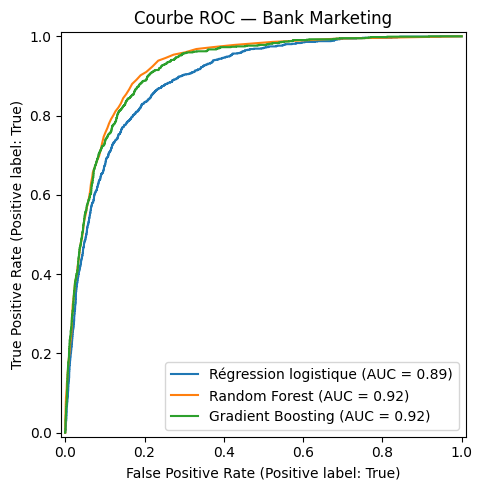

In [9]:
tracer_roc(competiteurs, X_test, y_test)

In [10]:
sauvegarder_champion(champion, champion_nom)

Champion sauvegardé : Random Forest → champion.joblib


In [11]:

# Notre champion bat-il la baseline (toujours 'no' -> recall yes = 0%) ?
#    oui, recall > 0
#
# La métrique ROC-AUC est-elle adaptée au coût métier ?
#    oui, cible déséquilibrée, l'accuracy mentirait
#
# Le champion gagne-t-il en cross-val ou seulement sur un split chanceux ?
#    à compléter avec les scores ci-dessus
#
# À faire avant la soutenance : remplacer pd.get_dummies + dropna() par le vrai
# pipeline preprocessing, relancer tout le notebook, mettre à jour le leaderboard dans le README.

## Questions ouvertes 

Chaque question est une décision de preprocessing : on change une seule chose à la fois, on mesure ROC-AUC + recall(yes) sur le même split, et c'est le score qui tranche.

In [20]:
# 1. duration : avec vs sans
print('=== DURATION : avec vs sans ===\n')
for label, path in [
    ('avec duration', '../data/bank_processed.csv'),
    ('sans duration', '../data/bank_processed_no_duration.csv'),
]:
    df_tmp = pd.read_csv(path)
    df_clean = pd.get_dummies(df_tmp, drop_first=True).dropna()
    X_tmp = df_clean.drop(columns=['y_yes'])
    y_tmp = df_clean['y_yes']
    X_tr, X_te, y_tr, y_te = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=42, stratify=y_tmp)
    m = GradientBoostingClassifier(n_estimators=100, random_state=42)
    m.fit(X_tr, y_tr)
    roc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    rec = recall_score(y_te, m.predict(X_te))
    print(f'{label:22s} → ROC-AUC : {roc:.3f} | Recall (yes) : {rec:.3f}')
print('\n→ Si l\'écart est grand : duration est une fuite de données, on retient le modèle sans.')

=== DURATION : avec vs sans ===

avec duration          → ROC-AUC : 0.916 | Recall (yes) : 0.391
sans duration          → ROC-AUC : 0.777 | Recall (yes) : 0.204

→ Si l'écart est grand : duration est une fuite de données, on retient le modèle sans.


In [21]:
# 2. class_weight : défaut vs balanced 
# GradientBoosting n'a pas class_weight → comparaison sur LR et RF uniquement
print('=== CLASS_WEIGHT : défaut vs balanced ===\n')
print(f'{"Algo":25s}  {"défaut ROC|Rec":>18s}  {"balanced ROC|Rec":>18s}')
print('─' * 65)
for nom, m_def, m_bal in [
    ('Régression logistique',
     LogisticRegression(max_iter=1000, random_state=42),
     LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, random_state=42),
     RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
]:
    row = []
    for m in [m_def, m_bal]:
        m.fit(X_train, y_train)
        roc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
        rec = recall_score(y_test, m.predict(X_test))
        row.append(f'{roc:.3f} | {rec:.3f}')
    print(f'{nom:25s}  {row[0]:>18s}  {row[1]:>18s}')
print('\n→ balanced augmente le recall(yes) mais peut dégrader le ROC-AUC : choisir selon le coût métier.')

=== CLASS_WEIGHT : défaut vs balanced ===

Algo                           défaut ROC|Rec    balanced ROC|Rec
─────────────────────────────────────────────────────────────────
Régression logistique           0.893 | 0.308       0.898 | 0.795
Random Forest                   0.921 | 0.390       0.920 | 0.335

→ balanced augmente le recall(yes) mais peut dégrader le ROC-AUC : choisir selon le coût métier.


In [22]:
# 3. month : one-hot vs ordinal vs cyclique
ORDRE_MOIS = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
              'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

print('=== MONTH : one-hot vs ordinal vs cyclique ===\n')
for label in ['one-hot', 'ordinal', 'cyclique']:
    df_tmp = df.copy()
    if label == 'ordinal':
        df_tmp['month'] = df_tmp['month'].map({m: i + 1 for i, m in enumerate(ORDRE_MOIS)})
    elif label == 'cyclique':
        month_num = df_tmp['month'].map({m: i + 1 for i, m in enumerate(ORDRE_MOIS)})
        df_tmp['month_sin'] = np.sin(2 * np.pi * month_num / 12)
        df_tmp['month_cos'] = np.cos(2 * np.pi * month_num / 12)
        df_tmp = df_tmp.drop(columns=['month'])
    df_clean = pd.get_dummies(df_tmp, drop_first=True).dropna()
    X_tmp = df_clean.drop(columns=['y_yes'])
    y_tmp = df_clean['y_yes']
    X_tr, X_te, y_tr, y_te = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=42, stratify=y_tmp)
    m = GradientBoostingClassifier(n_estimators=100, random_state=42)
    m.fit(X_tr, y_tr)
    roc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    rec = recall_score(y_te, m.predict(X_te))
    print(f'{label:12s} → ROC-AUC : {roc:.3f} | Recall (yes) : {rec:.3f}')
print('\n→ cyclique préserve la continuité déc→jan ; ordinal impose un ordre arbitraire ; one-hot est neutre mais ajoute 11 colonnes.')

=== MONTH : one-hot vs ordinal vs cyclique ===

one-hot      → ROC-AUC : 0.916 | Recall (yes) : 0.391
ordinal      → ROC-AUC : 0.917 | Recall (yes) : 0.369
cyclique     → ROC-AUC : 0.918 | Recall (yes) : 0.384

→ cyclique préserve la continuité déc→jan ; ordinal impose un ordre arbitraire ; one-hot est neutre mais ajoute 11 colonnes.


In [ ]:
#  4. unknown : catégorie séparée vs remplacement par le mode
COLS_UNKNOWN = ['job', 'education', 'contact', 'poutcome']

print('UNKNOWN : catégorie vs mode\n')
for label in ['catégorie (unknown)', 'mode']:
    df_tmp = df.copy()
    for col in COLS_UNKNOWN:
        if col not in df_tmp.columns:
            continue
        if label == 'catégorie (unknown)':
            df_tmp[col] = df_tmp[col].fillna('unknown')
        else:
            df_tmp[col] = df_tmp[col].fillna(df_tmp[col].mode()[0])
    df_clean = pd.get_dummies(df_tmp, drop_first=True).dropna()
    X_tmp = df_clean.drop(columns=['y_yes'])
    y_tmp = df_clean['y_yes']
    X_tr, X_te, y_tr, y_te = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=42, stratify=y_tmp)
    m = GradientBoostingClassifier(n_estimators=100, random_state=42)
    m.fit(X_tr, y_tr)
    roc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    rec = recall_score(y_te, m.predict(X_te))
    print(f'{label:25s} → ROC-AUC : {roc:.3f} | Recall (yes) : {rec:.3f}')
print('\n→ UCI documente unknown comme catégorie officielle ; si les scores sont équivalents, on la conserve (fidèle à la source).')

=== UNKNOWN : catégorie vs mode ===

catégorie (unknown)       → ROC-AUC : 0.923 | Recall (yes) : 0.403
mode                      → ROC-AUC : 0.917 | Recall (yes) : 0.387

→ UCI documente unknown comme catégorie officielle ; si les scores sont équivalents, on la conserve (fidèle à la source).
